# 🧠 Johansen CO₂ Bayesian Optimization — Handshake Mode v2

## Two Physical Conditions Enforced

| | Condition | Limit | Source |
|---|---|---|---|
| **1** | Caprock seal — BHP per injector | ≤ **360 bar** (all 5 injectors) | `simulation_summary.txt` → `BHP_WELL` lines |
| **2** | CO₂ containment — boundary saturation | S_CO₂ < **5%** at both boundary wells | `SBoundary_test_well.csv` + `SBoundary_test_well_2.csv` |

## Workflow
```
[Python] writes well_plan.csv  →  [You] run example3DJohansen.m in MATLAB
[MATLAB] writes bo_signal.json  →  [Python] reads result, updates Optuna
[Python] shows live progress chart  →  proposes next trial  →  repeat
```

In [1]:
# Cell 1 — Install dependencies
import subprocess, sys
for pkg in ['optuna', 'scikit-learn']:
    try:
        __import__(pkg.replace('-','_'))
        print(f'  ✅ {pkg}')
    except ImportError:
        print(f'  📦 Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  ✅ {pkg} installed')
print('\nAll dependencies ready.')

  ✅ optuna
  📦 Installing scikit-learn...
  ✅ scikit-learn installed

All dependencies ready.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# Cell 2 — Configuration
import os, re, glob, shutil, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import clear_output, display
warnings.filterwarnings('ignore')
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─── PATHS ────────────────────────────────────────────────────────────────────
MRST_ROOT      = '/Users/apple/Desktop/study/programming/Matlab/Plugins/MRST-2026a'
WELL_PLAN_PATH = f'{MRST_ROOT}/core/examples/data/Johansen/data/well_plan.csv'
BACKUP_CSV     = f'{MRST_ROOT}/core/examples/data/Johansen/data/well_plan_BACKUP_BO.csv'
WELL_CSVS_ROOT = f'{MRST_ROOT}/core/examples/data/Johansen/well_csvs'
PYTHON_DIR     = f'{MRST_ROOT}/core/examples/data/Johansen/python'
RESULTS_JSON   = f'{PYTHON_DIR}/bo_results.json'
SIGNAL_FILE    = f'{PYTHON_DIR}/bo_signal.json'
PENDING_FILE   = f'{PYTHON_DIR}/bo_pending.json'

# ─── OPTIMIZATION CONFIG ──────────────────────────────────────────────────────
N_TRIALS         = 40       # Total Bayesian trials
N_WARMUP         = 10       # Pure random warm-up
BHP_LIMIT_BAR    = 360.0    # Caprock seal limit — Condition 1
S_CO2_THRESHOLD  = 0.05     # Critical saturation (Johansen rel-perm) — Condition 2
PENALTY_BHP      = 50.0     # Penalty per bar above BHP limit (per injector)
PENALTY_CO2_LEAK = 500.0    # Penalty if S_CO2 >= threshold at boundary well

# ─── ACTIVE INJECTORS ─────────────────────────────────────────────────────────
DEEP_WELLS     = ['31/01/01', '31/1-3 S', '31/2-5', '31/05/02']
CENTRAL_WELL   = '31/05/07'
ALL_INJECTORS  = DEEP_WELLS + [CENTRAL_WELL]  # 5 wells — all checked for Cond 1

# ─── BOUNDARY SURVEILLANCE WELLS ──────────────────────────────────────────────
BOUNDARY_WELLS = ['SBoundary_test_well', 'SBoundary_test_well_2']  # Cond 2

# ─── SEARCH SPACE — T_end capped at 200 yr ───────────────────────────────────
BOUNDS = {
    'Q_deep'      : (0.3,  3.0),   # Mt/yr per deep well
    'Q_central'   : (0.3,  3.0),   # Mt/yr central well
    'T_start_deep': (0,    20),
    'T_end_deep'  : (30,   200),   # ← max 200 yr
    'T_start_cen' : (0,    20),
    'T_end_cen'   : (30,   200),   # ← max 200 yr
}

print('✅ Configuration loaded.')
print(f'   BHP limit         : {BHP_LIMIT_BAR} bar  (Condition 1, all {len(ALL_INJECTORS)} injectors)')
print(f'   S_CO2 threshold   : {S_CO2_THRESHOLD*100:.0f}%   (Condition 2, critical saturation)')
print(f'   T_end max         : {BOUNDS["T_end_deep"][1]} yr')
print(f'   Boundary wells    : {BOUNDARY_WELLS}')

✅ Configuration loaded.
   BHP limit         : 360.0 bar  (Condition 1, all 5 injectors)
   S_CO2 threshold   : 5%   (Condition 2, critical saturation)
   T_end max         : 200 yr
   Boundary wells    : ['SBoundary_test_well', 'SBoundary_test_well_2']


In [3]:
# Cell 3 — Utility Functions

def backup_well_plan():
    if not os.path.exists(BACKUP_CSV):
        shutil.copy2(WELL_PLAN_PATH, BACKUP_CSV)
        print(f'✅ Backup saved → {BACKUP_CSV}')
    else:
        print(f'ℹ️  Backup already exists (safe).')

def restore_well_plan():
    if os.path.exists(BACKUP_CSV):
        shutil.copy2(BACKUP_CSV, WELL_PLAN_PATH)
        print('✅ Original well_plan.csv restored.')
    else:
        print('⚠️ No backup found.')

def write_well_plan(Q_deep, T_start_deep, T_end_deep, Q_central, T_start_cen, T_end_cen):
    df = pd.read_csv(BACKUP_CSV)
    T_start_deep = int(T_start_deep)
    T_end_deep   = max(int(T_end_deep), T_start_deep + 10)
    T_start_cen  = int(T_start_cen)
    T_end_cen    = max(int(T_end_cen), T_start_cen + 10)
    for well in DEEP_WELLS:
        mask = df['Well_Bore_Name'] == well
        if mask.any():
            df.loc[mask, 'Rate_MtPerYear'] = round(Q_deep, 4)
            df.loc[mask, 'Start_Year']     = T_start_deep
            df.loc[mask, 'End_Year']       = T_end_deep
    mask_cen = df['Well_Bore_Name'] == CENTRAL_WELL
    if mask_cen.any():
        df.loc[mask_cen, 'Rate_MtPerYear'] = round(Q_central, 4)
        df.loc[mask_cen, 'Start_Year']     = T_start_cen
        df.loc[mask_cen, 'End_Year']       = T_end_cen
    df.to_csv(WELL_PLAN_PATH, index=False)

def get_latest_run_folder():
    folders = sorted([d for d in glob.glob(f'{WELL_CSVS_ROOT}/??_??_????__??_??') if os.path.isdir(d)])
    return folders[-1] if folders else None

# ── Condition 1: Per-injector BHP ─────────────────────────────────────────────
def parse_per_injector_bhp(folder):
    """
    Returns dict {well_name: peak_bhp_bar} for every injector.
    Reads the 'BHP_WELL <name> : <value> bar' lines from simulation_summary.txt.
    Falls back to the single 'Peak injector BHP' line if new format not present.
    """
    path = os.path.join(folder, 'simulation_summary.txt')
    if not os.path.exists(path):
        return {}
    text = open(path).read()
    result = {}
    # New per-well format
    for m in re.finditer(r'BHP_WELL\s+([\w/\s\-]+?)\s*:\s*([\d.]+)\s*bar', text):
        name = m.group(1).strip()
        result[name] = float(m.group(2))
    # Fallback: single peak BHP applied to first injector
    if not result:
        m_peak = re.search(r'Peak injector BHP\s*:\s*([\d.]+)', text)
        if m_peak:
            result['__peak__'] = float(m_peak.group(1))
    return result

# ── Condition 2: CO₂ boundary saturation ──────────────────────────────────────
def parse_boundary_saturation(folder):
    """
    Returns dict {well_name: max_S_CO2} for each boundary surveillance well.
    Reads all S_CO2_Lx columns in the boundary well CSVs.
    Returns NaN if CSV not found (well not yet in simulation, treat as safe).
    """
    result = {}
    for well in BOUNDARY_WELLS:
        safe = re.sub(r'[/ ]', '_', well)
        csv_path = os.path.join(folder, f'{safe}.csv')
        if not os.path.exists(csv_path):
            result[well] = float('nan')
            continue
        df = pd.read_csv(csv_path)
        s_cols = [c for c in df.columns if c.startswith('S_CO2_')]
        if not s_cols:
            result[well] = 0.0
            continue
        result[well] = float(df[s_cols].max().max())
    return result

# ── General summary parse (CO2 total) ─────────────────────────────────────────
def parse_co2_total(folder):
    path = os.path.join(folder, 'simulation_summary.txt')
    if not os.path.exists(path):
        return None
    m = re.search(r'Total CO2 injected\s*:\s*([\d.]+)', open(path).read())
    return float(m.group(1)) if m else None

def clear_signal():
    if os.path.exists(SIGNAL_FILE): os.remove(SIGNAL_FILE)

def save_results():
    with open(RESULTS_JSON, 'w') as f:
        json.dump(trial_log, f, indent=2)

def write_pending(trial_num, params):
    data = {**params, 'trial': trial_num, 'written_at': time.strftime('%Y-%m-%d %H:%M:%S')}
    with open(PENDING_FILE, 'w') as f:
        json.dump(data, f, indent=2)

print('✅ All utility functions defined.')

✅ All utility functions defined.


In [4]:
# Cell 4 — Live Progress Chart (renders after every trial)

def render_live_chart(trial_log, current_trial_num=None, current_params=None):
    """
    Clears notebook output and draws a live 3-panel progress dashboard.
    Call this inside the optimization loop after every completed trial.
    """
    ok = [t for t in trial_log if t.get('status') == 'OK']
    if not ok:
        return

    df = pd.DataFrame(ok)
    df['trial_num'] = df['trial'].astype(int) + 1
    df['cummax_co2'] = df['co2_mt'].cummax()

    # Classify each trial
    def classify(row):
        if row.get('cond1_breach', False) and row.get('cond2_breach', False):
            return '🔴 Both breach'
        elif row.get('cond1_breach', False):
            return '🟠 BHP breach'
        elif row.get('cond2_breach', False):
            return '🟡 CO₂ leak'
        else:
            return '🟢 Safe'
    df['status_label'] = df.apply(classify, axis=1)

    color_map = {
        '🟢 Safe'       : '#2ca02c',
        '🟠 BHP breach' : '#ff7f0e',
        '🟡 CO₂ leak'   : '#d4c400',
        '🔴 Both breach': '#d62728',
    }
    colors = df['status_label'].map(color_map).fillna('#aaaaaa')

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    fig.suptitle(
        f'Bayesian Optimization — Trial {len(trial_log)}/{N_TRIALS} | '
        f'Best safe CO₂: {df[~df.get("cond1_breach", pd.Series([False]*len(df))) & ~df.get("cond2_breach", pd.Series([False]*len(df)))]["co2_mt"].max():.2f} Mt'
        if any(not t.get("cond1_breach") and not t.get("cond2_breach") for t in ok) else
        f'Bayesian Optimization — Trial {len(trial_log)}/{N_TRIALS} | No safe trial yet',
        fontsize=12, fontweight='bold'
    )

    # ── Panel 1: CO2 stored per trial ────────────────────────────────────────
    ax = axes[0]
    ax.scatter(df['trial_num'], df['co2_mt'], c=colors, s=65, zorder=3, edgecolors='k', lw=0.4)
    ax.plot(df['trial_num'], df['cummax_co2'], 'k--', lw=1.8, label='Running best')
    # Legend patches
    from matplotlib.patches import Patch
    handles = [Patch(color=v, label=k) for k, v in color_map.items()]
    handles.append(plt.Line2D([0],[0], ls='--', color='k', label='Running best'))
    ax.legend(handles=handles, fontsize=8, loc='upper left')
    ax.set(xlabel='Trial #', ylabel='CO₂ Injected (Mt)', title='CO₂ per Trial')
    ax.grid(True, ls='--', alpha=0.35)

    # ── Panel 2: Condition 1 — per-trial max injector BHP ────────────────────
    ax = axes[1]
    if 'max_bhp_bar' in df.columns:
        bar_colors = ['#d62728' if b > BHP_LIMIT_BAR else '#1f77b4' for b in df['max_bhp_bar']]
        ax.bar(df['trial_num'], df['max_bhp_bar'], color=bar_colors, width=0.7, edgecolor='k', lw=0.3)
        ax.axhline(BHP_LIMIT_BAR, color='red', ls='--', lw=2, label=f'Limit: {BHP_LIMIT_BAR} bar')
        ax.legend(fontsize=9)
    ax.set(xlabel='Trial #', ylabel='Peak BHP (bar)', title='Condition 1 — Max Injector BHP')
    ax.grid(True, ls='--', alpha=0.35, axis='y')

    # ── Panel 3: Condition 2 — boundary S_CO2 ────────────────────────────────
    ax = axes[2]
    for bw_col, marker, label_suffix in [
        ('max_sco2_bw1', 'o', 'BW-1'),
        ('max_sco2_bw2', 's', 'BW-2'),
    ]:
        if bw_col in df.columns:
            vals = df[bw_col].fillna(0)
            dot_c = ['#d62728' if v >= S_CO2_THRESHOLD else '#2ca02c' for v in vals]
            ax.scatter(df['trial_num'], vals * 100, c=dot_c, marker=marker,
                       s=60, zorder=3, edgecolors='k', lw=0.4, label=label_suffix)
    ax.axhline(S_CO2_THRESHOLD * 100, color='red', ls='--', lw=2,
               label=f'Limit: {S_CO2_THRESHOLD*100:.0f}%')
    ax.legend(fontsize=9)
    ax.set(xlabel='Trial #', ylabel='Max S_CO₂ (%)', title='Condition 2 — Boundary CO₂ Saturation')
    ax.grid(True, ls='--', alpha=0.35)

    plt.tight_layout()

    # Show current pending trial params if provided
    if current_params:
        param_str = (
            f"Next: Q_deep={current_params.get('Q_deep',0):.2f} Mt/yr "
            f"T=[{current_params.get('T_start_deep',0)}->{current_params.get('T_end_deep',0)}] | "
            f"Q_cen={current_params.get('Q_central',0):.2f} Mt/yr "
            f"T=[{current_params.get('T_start_cen',0)}->{current_params.get('T_end_cen',0)}]"
        )
        fig.text(0.5, -0.02, param_str, ha='center', fontsize=9, color='navy',
                 style='italic', bbox=dict(boxstyle='round', facecolor='#e8f4fd', alpha=0.8))

    plt.savefig(f'{PYTHON_DIR}/bo_live_progress.png', dpi=120, bbox_inches='tight')
    plt.show()

print('✅ Live chart function defined.')

✅ Live chart function defined.


In [5]:
# Cell 5 — Backup & Verify Setup
backup_well_plan()

df_plan = pd.read_csv(BACKUP_CSV)
active = df_plan[df_plan['Rate_MtPerYear'] > 0]
print('\n📋 Active wells in base configuration:')
print(active[['Well_Bore_Name','Rate_MtPerYear','Start_Year','End_Year']].to_string(index=False))

# Verify boundary well CSVs parse correctly on the latest run
latest = get_latest_run_folder()
if latest:
    print(f'\n🔍 Parsing latest run: {os.path.basename(latest)}')
    bhp_dict = parse_per_injector_bhp(latest)
    bsat_dict = parse_boundary_saturation(latest)
    co2_val   = parse_co2_total(latest)

    print(f'   CO₂ total : {co2_val} Mt')
    print(f'   Per-injector BHP:')
    for k, v in bhp_dict.items():
        breach = '🚨 BREACH' if v > BHP_LIMIT_BAR else '✅'
        print(f'     {k:25s}: {v:6.1f} bar  {breach}')
    print(f'   Boundary S_CO₂:')
    for k, v in bsat_dict.items():
        if v != v:  # NaN
            print(f'     {k:30s}: CSV not found (will be generated from next run)')
        else:
            breach = '🚨 BREACH' if v >= S_CO2_THRESHOLD else '✅'
            print(f'     {k:30s}: {v*100:5.2f}%  {breach}')

clear_signal()
if os.path.exists(PENDING_FILE): os.remove(PENDING_FILE)
print('\n✅ All pre-flight checks done. Run Cell 6 (resume) then Cell 7 (optimize).')

ℹ️  Backup already exists (safe).

📋 Active wells in base configuration:
Well_Bore_Name  Rate_MtPerYear  Start_Year  End_Year
      31/01/01           0.875           0        50
      31/1-3 S           0.875           0        25
        31/2-5           0.875           0        25
        31/4-3           1.250        9999      9999
      31/05/02           1.250           0        25
      31/05/07           2.250           0        50
      31/07/01           2.000           0        25

🔍 Parsing latest run: 31_07_2026__22_58
   CO₂ total : None Mt
   Per-injector BHP:
   Boundary S_CO₂:
     SBoundary_test_well           : CSV not found (will be generated from next run)
     SBoundary_test_well_2         : CSV not found (will be generated from next run)

✅ All pre-flight checks done. Run Cell 6 (resume) then Cell 7 (optimize).


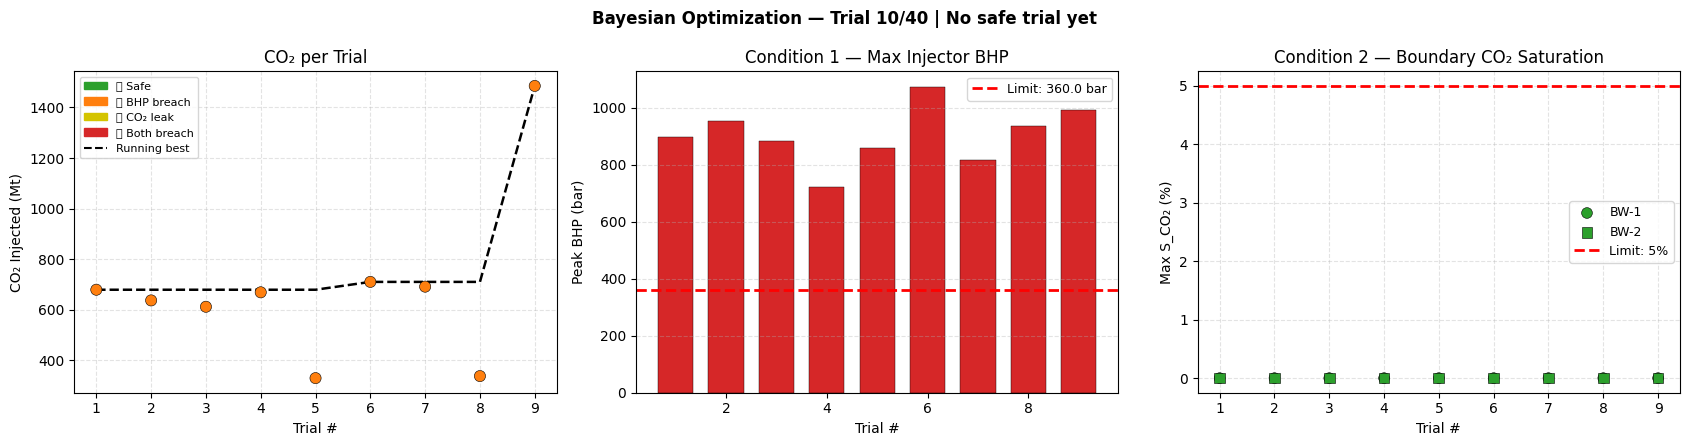

In [6]:
# Cell 6 — (Optional) Resume from Previous Run
# Run BEFORE Cell 7 if you are continuing after an interruption.

if os.path.exists(RESULTS_JSON):
    with open(RESULTS_JSON) as f:
        trial_log = json.load(f)
    ok = [t for t in trial_log if t.get('status') == 'OK']
    print(f'📂 Loaded {len(trial_log)} previous trials ({len(ok)} successful).')
    if ok:
        best = max(ok, key=lambda x: x.get('co2_mt', 0)
                   if not x.get('cond1_breach') and not x.get('cond2_breach') else -9999)
        print(f'   Best safe result: CO₂={best.get("co2_mt", 0):.2f} Mt')
    remaining = max(0, N_TRIALS - len(trial_log))
    print(f'   Trials remaining: {remaining}')
    if ok:
        render_live_chart(trial_log)
else:
    trial_log = []
    print('ℹ️  No previous results — starting fresh.')

In [7]:
# Cell 7 — Define Objective Function
trial_log = trial_log if 'trial_log' in dir() else []

def wait_for_matlab(trial_num, params, poll_seconds=30):
    """
    Wait for bo_signal.json (written by MATLAB at end of example3DJohansen.m).
    Shows live progress chart while waiting. Returns run_folder or None.
    """
    clear_signal()
    waited = 0
    print(f'  ⏳ Waiting for MATLAB  (polls every {poll_seconds}s) ...')
    print(f'  ▶  Switch to MATLAB and run:  example3DJohansen.m')
    try:
        while True:
            time.sleep(poll_seconds)
            waited += poll_seconds
            if os.path.exists(SIGNAL_FILE):
                with open(SIGNAL_FILE) as f:
                    signal = json.load(f)
                clear_signal()
                run_folder = signal.get('run_folder', '')
                print(f'  ✅ Signal received after {waited//60}m {waited%60}s')
                return run_folder
            else:
                print(f'  ... {waited//60}m {waited%60}s elapsed — still waiting.')
    except KeyboardInterrupt:
        print('  ⚡ Wait skipped by user — checking for latest folder.')
        clear_signal()
        return get_latest_run_folder()

def objective(trial):
    # ── Propose parameters ────────────────────────────────────────────────────
    Q_deep       = trial.suggest_float('Q_deep',       *BOUNDS['Q_deep'],       step=0.05)
    T_start_deep = trial.suggest_int(  'T_start_deep', *BOUNDS['T_start_deep'])
    T_end_deep   = trial.suggest_int(  'T_end_deep',   *BOUNDS['T_end_deep'])
    Q_central    = trial.suggest_float('Q_central',    *BOUNDS['Q_central'],    step=0.05)
    T_start_cen  = trial.suggest_int(  'T_start_cen',  *BOUNDS['T_start_cen'])
    T_end_cen    = trial.suggest_int(  'T_end_cen',    *BOUNDS['T_end_cen'])

    if T_start_deep >= T_end_deep or T_start_cen >= T_end_cen:
        trial_log.append({'trial': trial.number, 'status': 'SKIPPED', 'reason': 'T_start>=T_end'})
        save_results()
        return 9999.0

    params = {
        'Q_deep': Q_deep, 'T_start_deep': T_start_deep, 'T_end_deep': T_end_deep,
        'Q_central': Q_central, 'T_start_cen': T_start_cen, 'T_end_cen': T_end_cen,
    }
    phase = 'WARMUP (random)' if trial.number < N_WARMUP else 'BO-GUIDED'

    print()
    print('═' * 64)
    print(f'  TRIAL {trial.number+1}/{N_TRIALS}  [{phase}]')
    print('═' * 64)
    print(f'  Deep wells  : Q = {Q_deep:.2f} Mt/yr   T = [{T_start_deep} → {T_end_deep}] yr')
    print(f'  Central well: Q = {Q_central:.2f} Mt/yr   T = [{T_start_cen} → {T_end_cen}] yr')

    # ── Write well_plan.csv ───────────────────────────────────────────────────
    write_well_plan(Q_deep, T_start_deep, T_end_deep, Q_central, T_start_cen, T_end_cen)
    write_pending(trial.number, params)
    print(f'  ✅ well_plan.csv updated.')

    # ── Wait for MATLAB ───────────────────────────────────────────────────────
    run_folder = wait_for_matlab(trial.number, params)
    if run_folder is None:
        trial_log.append({**params, 'trial': trial.number, 'status': 'FAILED'})
        save_results()
        return 9999.0

    # ── Parse CO₂ total ───────────────────────────────────────────────────────
    co2_mt = parse_co2_total(run_folder)
    if co2_mt is None:
        trial_log.append({**params, 'trial': trial.number, 'status': 'PARSE_ERROR'})
        save_results()
        return 9999.0

    # ── Condition 1: Per-injector BHP check ───────────────────────────────────
    bhp_dict = parse_per_injector_bhp(run_folder)
    cond1_breach = False
    cond1_penalty = 0.0
    cond1_details = {}
    if '__peak__' in bhp_dict:
        # Fallback (old summary format)
        peak = bhp_dict['__peak__']
        excess = max(0.0, peak - BHP_LIMIT_BAR)
        cond1_penalty += PENALTY_BHP * excess
        cond1_breach = excess > 0
        cond1_details['__peak__'] = peak
    else:
        for inj_well in ALL_INJECTORS:
            bhp_w = bhp_dict.get(inj_well, None)
            if bhp_w is None:
                continue
            excess = max(0.0, bhp_w - BHP_LIMIT_BAR)
            cond1_penalty += PENALTY_BHP * excess
            cond1_details[inj_well] = bhp_w
            if excess > 0:
                cond1_breach = True
    max_bhp = max(cond1_details.values()) if cond1_details else float('nan')

    # ── Condition 2: Boundary CO₂ saturation ──────────────────────────────────
    bsat = parse_boundary_saturation(run_folder)
    cond2_breach = False
    cond2_penalty = 0.0
    bw1_val = bsat.get(BOUNDARY_WELLS[0], 0.0) if bsat.get(BOUNDARY_WELLS[0], 0.0) == bsat.get(BOUNDARY_WELLS[0], 0.0) else 0.0
    bw2_val = bsat.get(BOUNDARY_WELLS[1], 0.0) if bsat.get(BOUNDARY_WELLS[1], 0.0) == bsat.get(BOUNDARY_WELLS[1], 0.0) else 0.0
    for bw_name, bw_val in [(BOUNDARY_WELLS[0], bw1_val), (BOUNDARY_WELLS[1], bw2_val)]:
        if bw_val >= S_CO2_THRESHOLD:
            cond2_breach = True
            cond2_penalty += PENALTY_CO2_LEAK * (bw_val - S_CO2_THRESHOLD)

    # ── Compute reward ────────────────────────────────────────────────────────
    total_penalty = cond1_penalty + cond2_penalty
    reward = co2_mt - total_penalty

    # ── Print result ──────────────────────────────────────────────────────────
    c1_str = f'🚨 BREACH (max={max_bhp:.1f} bar, pen={cond1_penalty:.0f})' if cond1_breach else f'✅ safe (max={max_bhp:.1f} bar)'
    c2_str = f'🚨 BREACH (BW1={bw1_val*100:.2f}% BW2={bw2_val*100:.2f}%, pen={cond2_penalty:.0f})' if cond2_breach else f'✅ safe (BW1={bw1_val*100:.2f}% BW2={bw2_val*100:.2f}%)'
    print(f'  CO₂ injected : {co2_mt:.2f} Mt')
    print(f'  Cond 1 (BHP) : {c1_str}')
    print(f'  Cond 2 (S)   : {c2_str}')
    print(f'  Reward       : {reward:.2f}')

    # ── Log & save ────────────────────────────────────────────────────────────
    entry = {
        **params,
        'trial': trial.number, 'run_folder': os.path.basename(run_folder),
        'status': 'OK', 'co2_mt': co2_mt,
        'max_bhp_bar': max_bhp,
        'cond1_breach': cond1_breach, 'cond1_penalty': cond1_penalty,
        'max_sco2_bw1': bw1_val, 'max_sco2_bw2': bw2_val,
        'cond2_breach': cond2_breach, 'cond2_penalty': cond2_penalty,
        'total_penalty': total_penalty, 'reward': reward,
    }
    trial_log.append(entry)
    save_results()

    # ── Live chart update ─────────────────────────────────────────────────────
    render_live_chart(trial_log)

    return -reward

print('✅ Objective function defined.')

✅ Objective function defined.


In [ ]:
# Cell 8 — 🚀 START / CONTINUE Optimization
#
# Steps:
#   1. Run Cell 1-7 (setup)
#   2. Run Cell 6 to resume OR skip Cell 6 to start fresh
#   3. Run this cell → see "Run MATLAB now" prompt
#   4. Go to MATLAB → run example3DJohansen.m
#   5. Return here — charts auto-update after each trial
#   6. Ctrl+C to pause; re-run Cell 6 + Cell 8 to resume

print('═' * 64)
print('  JOHANSEN CO₂ BAYESIAN OPTIMIZATION — HANDSHAKE MODE v2')
print('═' * 64)
print(f'  N_TRIALS         : {N_TRIALS}  ({N_WARMUP} random + {N_TRIALS-N_WARMUP} BO-guided)')
print(f'  Condition 1 (BHP): ≤ {BHP_LIMIT_BAR} bar per injector')
print(f'  Condition 2 (S)  : S_CO₂ < {S_CO2_THRESHOLD*100:.0f}% at boundary wells')
print(f'  T_end max        : {BOUNDS["T_end_deep"][1]} yr')
print('═' * 64)

sampler   = TPESampler(n_startup_trials=N_WARMUP, seed=42)
study     = optuna.create_study(study_name='johansen_co2_v2', direction='minimize', sampler=sampler)
remaining = max(0, N_TRIALS - len(trial_log))

if remaining == 0:
    print('\n✅ All trials complete. Jump to analysis cells (9–13).')
    render_live_chart(trial_log)
else:
    print(f'\n  {remaining} trial(s) to run — you will be prompted {remaining} times to run MATLAB.\n')
    try:
        study.optimize(objective, n_trials=remaining, gc_after_trial=True, show_progress_bar=False)
    except KeyboardInterrupt:
        print('\n⚡ Paused. Run Cell 6 + Cell 8 to resume.')

    ok = [t for t in trial_log if t.get('status') == 'OK']
    safe = [t for t in ok if not t.get('cond1_breach') and not t.get('cond2_breach')]
    if safe:
        best = max(safe, key=lambda x: x.get('co2_mt', 0))
        print(f'\n🏆 BEST SAFE RESULT:')
        print(f'   CO₂ stored  : {best["co2_mt"]:.2f} Mt')
        print(f'   Max BHP     : {best["max_bhp_bar"]:.1f} bar')
        print(f'   Deep wells  : Q={best["Q_deep"]:.2f} T=[{int(best["T_start_deep"])}->{int(best["T_end_deep"])}] yr')
        print(f'   Central     : Q={best["Q_central"]:.2f} T=[{int(best["T_start_cen"])}->{int(best["T_end_cen"])}] yr')
    else:
        print('\n⚠️  No fully-safe trial yet. Consider reducing Q bounds.')

════════════════════════════════════════════════════════════════
  JOHANSEN CO₂ BAYESIAN OPTIMIZATION — HANDSHAKE MODE v2
════════════════════════════════════════════════════════════════
  N_TRIALS         : 40  (10 random + 30 BO-guided)
  Condition 1 (BHP): ≤ 360.0 bar per injector
  Condition 2 (S)  : S_CO₂ < 5% at boundary wells
  T_end max        : 200 yr
════════════════════════════════════════════════════════════════

  30 trial(s) to run — you will be prompted 30 times to run MATLAB.


════════════════════════════════════════════════════════════════
  TRIAL 1/40  [WARMUP (random)]
════════════════════════════════════════════════════════════════
  Deep wells  : Q = 1.30 Mt/yr   T = [19 → 155] yr
  Central well: Q = 1.90 Mt/yr   T = [3 → 56] yr
  ✅ well_plan.csv updated.
  ⏳ Waiting for MATLAB  (polls every 30s) ...
  ▶  Switch to MATLAB and run:  example3DJohansen.m
  ⚡ Wait skipped by user — checking for latest folder.

══════════════════════════════════════════════════════════

In [ ]:
# Cell 9 — Results Summary

if os.path.exists(RESULTS_JSON):
    with open(RESULTS_JSON) as f:
        trial_log = json.load(f)

df_all  = pd.DataFrame(trial_log)
df_ok   = df_all[df_all['status'] == 'OK'].copy() if not df_all.empty else pd.DataFrame()
df_safe = df_ok[~df_ok['cond1_breach'] & ~df_ok['cond2_breach']] if not df_ok.empty else pd.DataFrame()

print(f'Total trials      : {len(df_all)}')
print(f'Successful runs   : {len(df_ok)}')
print(f'Cond1 breaches    : {df_ok["cond1_breach"].sum() if not df_ok.empty else 0}  (BHP > 360 bar)')
print(f'Cond2 breaches    : {df_ok["cond2_breach"].sum() if not df_ok.empty else 0}  (S_CO₂ ≥ 5%)')
print(f'Fully safe trials : {len(df_safe)}')

if not df_safe.empty:
    best = df_safe.loc[df_safe['co2_mt'].idxmax()]
    print(f'\n🏆 BEST SAFE TRIAL #{int(best["trial"])+1}')
    print(f'   CO₂ stored  : {best["co2_mt"]:.2f} Mt')
    print(f'   Max BHP     : {best["max_bhp_bar"]:.1f} bar  (limit: {BHP_LIMIT_BAR})')
    print(f'   BW-1 S_CO₂  : {best["max_sco2_bw1"]*100:.3f}%  (limit: {S_CO2_THRESHOLD*100:.0f}%)')
    print(f'   BW-2 S_CO₂  : {best["max_sco2_bw2"]*100:.3f}%')
    print(f'   Deep wells  : Q={best["Q_deep"]:.2f} Mt/yr  T=[{int(best["T_start_deep"])}->{int(best["T_end_deep"])}] yr')
    print(f'   Central     : Q={best["Q_central"]:.2f} Mt/yr  T=[{int(best["T_start_cen"])}->{int(best["T_end_cen"])}] yr')

if not df_ok.empty:
    print(f'\n   CO₂ range   : {df_ok["co2_mt"].min():.1f} → {df_ok["co2_mt"].max():.1f} Mt')
    print(f'   BHP range   : {df_ok["max_bhp_bar"].min():.1f} → {df_ok["max_bhp_bar"].max():.1f} bar')

In [ ]:
# Cell 10 — Parameter Importance (Random Forest)
from sklearn.ensemble import RandomForestRegressor

if 'df_ok' not in dir() or len(df_ok) < 5:
    print('Run Cell 9 first (need ≥5 successful trials).')
else:
    param_cols = ['Q_deep','T_start_deep','T_end_deep','Q_central','T_start_cen','T_end_cen']
    X = df_ok[param_cols].values
    y = df_ok['co2_mt'].values
    rf = RandomForestRegressor(n_estimators=400, random_state=42)
    rf.fit(X, y)
    imp  = rf.feature_importances_
    sidx = np.argsort(imp)[::-1]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar([param_cols[i] for i in sidx], imp[sidx],
                  color=cm.plasma(np.linspace(0.15, 0.85, len(param_cols))),
                  edgecolor='k', lw=0.7)
    for bar, v in zip(bars, imp[sidx]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set(ylabel='Importance', title='Which Parameters Matter Most for CO₂ Storage?')
    ax.grid(True, ls='--', alpha=0.4, axis='y')
    plt.tight_layout()
    plt.savefig(f'{PYTHON_DIR}/bo_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Ranking:', [param_cols[i] for i in sidx])

In [ ]:
# Cell 11 — Surrogate Surface (Q_deep × T_end_deep)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

if 'df_ok' not in dir() or len(df_ok) < 5:
    print('Need ≥5 successful trials.')
else:
    param_cols = ['Q_deep','T_start_deep','T_end_deep','Q_central','T_start_cen','T_end_cen']
    X      = df_ok[param_cols].values
    y      = df_ok['co2_mt'].values
    scaler = StandardScaler()
    surr   = GradientBoostingRegressor(n_estimators=400, max_depth=4, random_state=42)
    surr.fit(scaler.fit_transform(X), y)
    best_row = df_ok.loc[df_ok['reward'].idxmax(), param_cols].values

    Q_g = np.linspace(*BOUNDS['Q_deep'], 60)
    T_g = np.linspace(*BOUNDS['T_end_deep'], 60)
    QQ, TT = np.meshgrid(Q_g, T_g)
    grid_pts = np.column_stack([
        QQ.ravel(), np.full(QQ.size, best_row[1]), TT.ravel(),
        np.full(QQ.size, best_row[3]), np.full(QQ.size, best_row[4]), np.full(QQ.size, best_row[5])
    ])
    Z = surr.predict(scaler.transform(grid_pts)).reshape(QQ.shape)

    fig, ax = plt.subplots(figsize=(9, 6))
    cf = ax.contourf(QQ, TT, Z, levels=25, cmap='YlOrRd')
    ax.contour(QQ, TT, Z, levels=12, colors='k', linewidths=0.4, alpha=0.35)
    plt.colorbar(cf, ax=ax, label='Predicted CO₂ (Mt)')
    ax.scatter(df_ok['Q_deep'], df_ok['T_end_deep'], c=df_ok['co2_mt'],
               cmap='YlOrRd', edgecolors='k', s=65, zorder=5, lw=0.8)
    best_safe = df_ok[~df_ok['cond1_breach'] & ~df_ok['cond2_breach']]
    if not best_safe.empty:
        bs = best_safe.loc[best_safe['co2_mt'].idxmax()]
        ax.scatter([bs['Q_deep']], [bs['T_end_deep']], s=280, marker='*',
                   color='blue', zorder=6, label='Best safe')
        ax.legend(fontsize=10)
    ax.set(xlabel='Q_deep (Mt/yr)', ylabel='T_end_deep (yr)',
           title=f'Surrogate Surface — CO₂ vs Q_deep & T_end_deep\n(other params at best values)')
    plt.tight_layout()
    plt.savefig(f'{PYTHON_DIR}/bo_surrogate.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# Cell 12 — Full Results Table

if 'df_ok' not in dir() or df_ok.empty:
    print('Run Cell 9 first.')
else:
    cols = ['trial','Q_deep','T_start_deep','T_end_deep','Q_central',
            'T_start_cen','T_end_cen','co2_mt','max_bhp_bar',
            'max_sco2_bw1','max_sco2_bw2','cond1_breach','cond2_breach','reward']
    avail = [c for c in cols if c in df_ok.columns]
    df_show = df_ok[avail].copy()
    df_show['trial'] = df_show['trial'].astype(int) + 1
    df_show = df_show.sort_values('reward', ascending=False).reset_index(drop=True)
    # Percentage format for saturations
    for col in ['max_sco2_bw1','max_sco2_bw2']:
        if col in df_show.columns:
            df_show[col] = df_show[col].apply(lambda v: f'{v*100:.3f}%')

    def row_style(row):
        s = [''] * len(row)
        if row.get('cond1_breach') or row.get('cond2_breach'):
            s = ['background-color:#fff0f0'] * len(row)
        if row.name == 0:
            s = ['background-color:#e8ffe8;font-weight:bold'] * len(row)
        return s

    fmt = {c: '{:.2f}' for c in ['Q_deep','Q_central','co2_mt','max_bhp_bar','reward']}
    display(df_show.style.apply(row_style, axis=1).format(fmt, na_rep='—'))

In [ ]:
# Cell 13 — Apply Best Safe Parameters to well_plan.csv

if 'df_ok' not in dir() or df_ok.empty:
    print('Run Cell 9 first.')
else:
    df_safe = df_ok[~df_ok['cond1_breach'] & ~df_ok['cond2_breach']]
    if df_safe.empty:
        print(f'⚠️  No fully-safe trials yet (BHP ≤ {BHP_LIMIT_BAR} bar AND S_CO₂ < {S_CO2_THRESHOLD*100:.0f}%).')
        print('   Applying best-reward result instead.')
        chosen = df_ok.loc[df_ok['reward'].idxmax()]
        mode = 'Best Reward (no safe trial exists)'
    else:
        chosen = df_safe.loc[df_safe['co2_mt'].idxmax()]
        mode = 'Best Safe (BHP + CO₂ constrained)'

    print(f'📝 Applying [{mode}]')
    print(f'   Deep: Q={chosen["Q_deep"]:.2f} Mt/yr  T=[{int(chosen["T_start_deep"])}->{int(chosen["T_end_deep"])}] yr')
    print(f'   Cen : Q={chosen["Q_central"]:.2f} Mt/yr  T=[{int(chosen["T_start_cen"])}->{int(chosen["T_end_cen"])}] yr')
    print(f'   Expected CO₂ : {chosen["co2_mt"]:.2f} Mt  |  Max BHP: {chosen["max_bhp_bar"]:.1f} bar')
    write_well_plan(chosen['Q_deep'],    int(chosen['T_start_deep']), int(chosen['T_end_deep']),
                    chosen['Q_central'], int(chosen['T_start_cen']),  int(chosen['T_end_cen']))
    print('\n✅ well_plan.csv updated. Run MATLAB for final validation.')

In [ ]:
# Cell 14 — Emergency Restore
# Run ONLY if you want to undo all BO changes to well_plan.csv

# restore_well_plan()
print('Uncomment restore_well_plan() to undo all changes.')